<a href="https://colab.research.google.com/github/Snowpuppies2020/Finance/blob/main/NT%E5%80%8D%E7%8E%87%E3%81%AE%E5%B9%B3%E5%9D%87%E4%B9%96%E9%9B%A2%E3%83%88%E3%83%AC%E3%83%BC%E3%83%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1598/3124556836.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_n225 = yf.download('1321.T', start='2015-01-01')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1598/3124556836.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_topix = yf.download('1306.T', start='2015-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


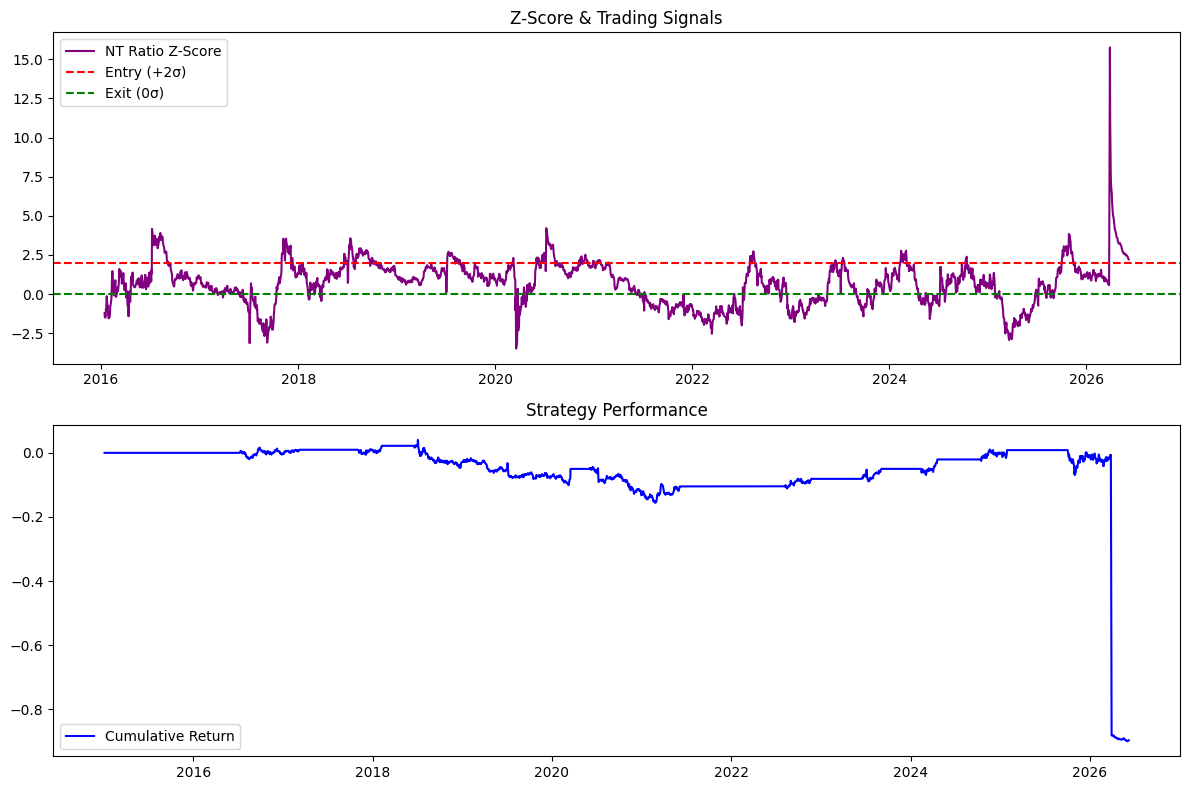

年率リターン: -18.39%
シャープレシオ: -0.34


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. データの取得 (2015年〜現在)
# 1321: 日経225 ETF, 1306: TOPIX ETF
df_n225 = yf.download('1321.T', start='2015-01-01')['Close']
df_topix = yf.download('1306.T', start='2015-01-01')['Close']

df = pd.concat([df_n225, df_topix], axis=1)
df.columns = ['N225', 'TOPIX']
df = df.dropna()

# 2. NT倍率とZスコアの計算
df['NT_Ratio'] = df['N225'] / df['TOPIX']
window = 252 # 1年移動平均

df['Mean'] = df['NT_Ratio'].rolling(window=window).mean()
df['Std'] = df['NT_Ratio'].rolling(window=window).std()
df['Z_Score'] = (df['NT_Ratio'] - df['Mean']) / df['Std']

# 3. トレードシグナルの生成 (+2σでショート、0で決済)
positions = np.zeros(len(df))
pos = 0
for i in range(len(df)):
    if pd.isna(df['Z_Score'].iloc[i]):
        positions[i] = 0
        continue

    z = df['Z_Score'].iloc[i]
    if z > 2.0:
        pos = -1 # 日経ショート / TOPIXロング
    elif pos == -1 and z < 0:
        pos = 0  # 決済
    positions[i] = pos

df['Position'] = positions

# 4. リターンの計算
df['N225_Ret'] = df['N225'].pct_change()
df['TOPIX_Ret'] = df['TOPIX'].pct_change()

# ペアトレードリターン (TOPIXロング - N225ショート)
df['Strategy_Ret'] = df['Position'].shift(1) * (df['N225_Ret'] - df['TOPIX_Ret'])
df['Cum_Ret'] = (1 + df['Strategy_Ret'].fillna(0)).cumprod() - 1

# 5. 結果のプロット
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(df.index, df['Z_Score'], label='NT Ratio Z-Score', color='purple')
plt.axhline(2.0, color='red', linestyle='--', label='Entry (+2σ)')
plt.axhline(0.0, color='green', linestyle='--', label='Exit (0σ)')
plt.legend()
plt.title('Z-Score & Trading Signals')

plt.subplot(2, 1, 2)
plt.plot(df.index, df['Cum_Ret'], label='Cumulative Return', color='blue')
plt.title('Strategy Performance')
plt.legend()
plt.tight_layout()
plt.show()

# 6. パフォーマンス指標の出力
ann_ret = (1 + df['Cum_Ret'].iloc[-1]) ** (252 / len(df)) - 1
sharpe = np.sqrt(252) * df['Strategy_Ret'].mean() / df['Strategy_Ret'].std()
print(f"年率リターン: {ann_ret:.2%}")
print(f"シャープレシオ: {sharpe:.2f}")